In [1]:
import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run


run = open_run("20260904203234")
run.info()

Run_ID,Sim_Type,Status,Directory,Trajectory,HDF5,Frame_Count
20260904203234,Thermalization,Complete,/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260904203234,/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260904203234/trajectory.gsd,/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260904203234/run.hdf5,6


Run_ID,Run_Signature,N_Cells,Nsteps,Current_Nstep,ElapsedTime,StartTime,EndTime,Last_Update_Time,Sim_Type,Status,Stop_Reason,Status_Message,Notes
20260904203234,5ebcafbdd251afd2e27243c0a76c24f739afec8dbcf220b3dbf060f985dec0ff,40,100000,100000,102.995823,2026-09-04 20:32:35.582500,2026-09-04 20:35:17.855084,2026-09-04 20:35:17.855084,Thermalization,Complete,None,None,None


Run_ID,File_Location,Clone_Run_ID,Clone_Frame_ID,Therm_kT,Therm_Seed,Density_Start,Density_End,BoxLength_Start,BoxLength_End,dt,Nsteps,This_LJ_Time,Cumulative_LJ_Time,Ensemble,T_Set,P_Set,LJ_r_cut,LJ_r_on,LJ_Mode,Phase_Separation_Status,Phase_Separation_Method,Phase_Separation_Method_Version,rho_liquid,rho_liquid_unc,rho_gas,rho_gas_unc,V_liquid,V_liquid_unc,V_gas,V_gas_unc,Phase_Fit_Status,Phase_Fit_Method,Phase_Fit_Method_Version,Summary_Start_Step,Summary_End_Step,Summary_Num_Samples,Pressure_Mean,Pressure_Std,Pressure_SEM,PE_Per_Particle_Mean,PE_Per_Particle_Std,PE_Per_Particle_SEM,Num_Frames,N_Cells
20260904203234,Thermalization/20260904203234,None,None,1.000000,1,0.600000,0.600000,75.282882,75.282882,0.002000,100000,200.000000,200.000000,NVT,1.000000,None,2.500000,2.000000,xplor,Not_Separated,voxel_histogram,voxel_low_density_fraction_v1,None,None,None,None,None,None,None,None,Skipped_Homogeneous,None,None,90100,100000,100,-0.008231,0.005913,0.000591,-3.785046,0.001764,0.000176,6,40


{'Run_ID': '20260904203234',
 'Sim_Type': 'Thermalization',
 'Status': 'Complete',
 'Directory': '/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260904203234',
 'Trajectory': '/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260904203234/trajectory.gsd',
 'HDF5': '/exp/e961/data/MDsims-data/pnichols/SQL/Thermalization/20260904203234/run.hdf5',
 'Frame_Count': 6}

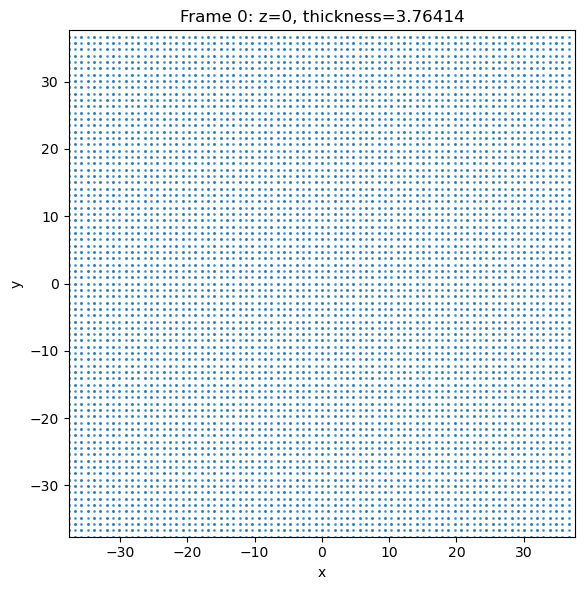

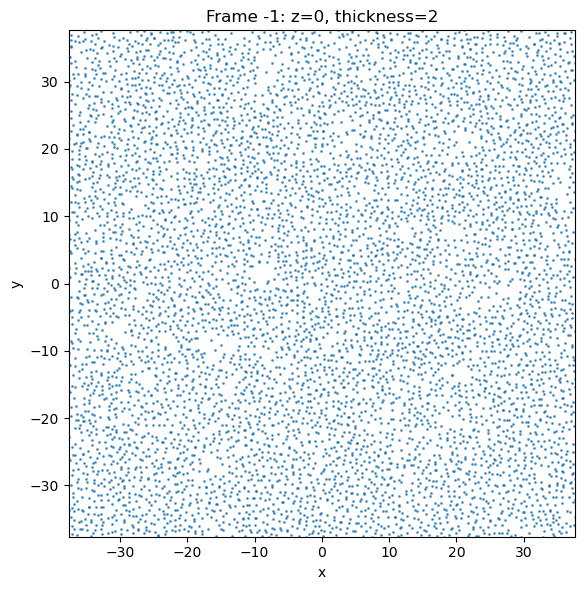

In [2]:
# 3D views
#run.render(frame=0)
#run.render(frame=-1)
#run.render_movie()

# XY slices
run.xy_slice(frame=0)
run.xy_slice(frame=-1, z=0, thickness=2.0);
#run.xy_slice(frames=[0, 10, 20, -1])
run.xy_slice_movie(frame_step=1);

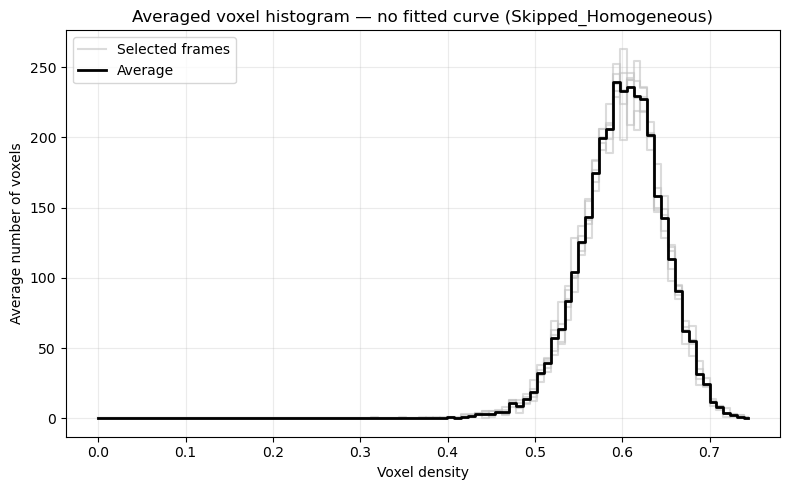

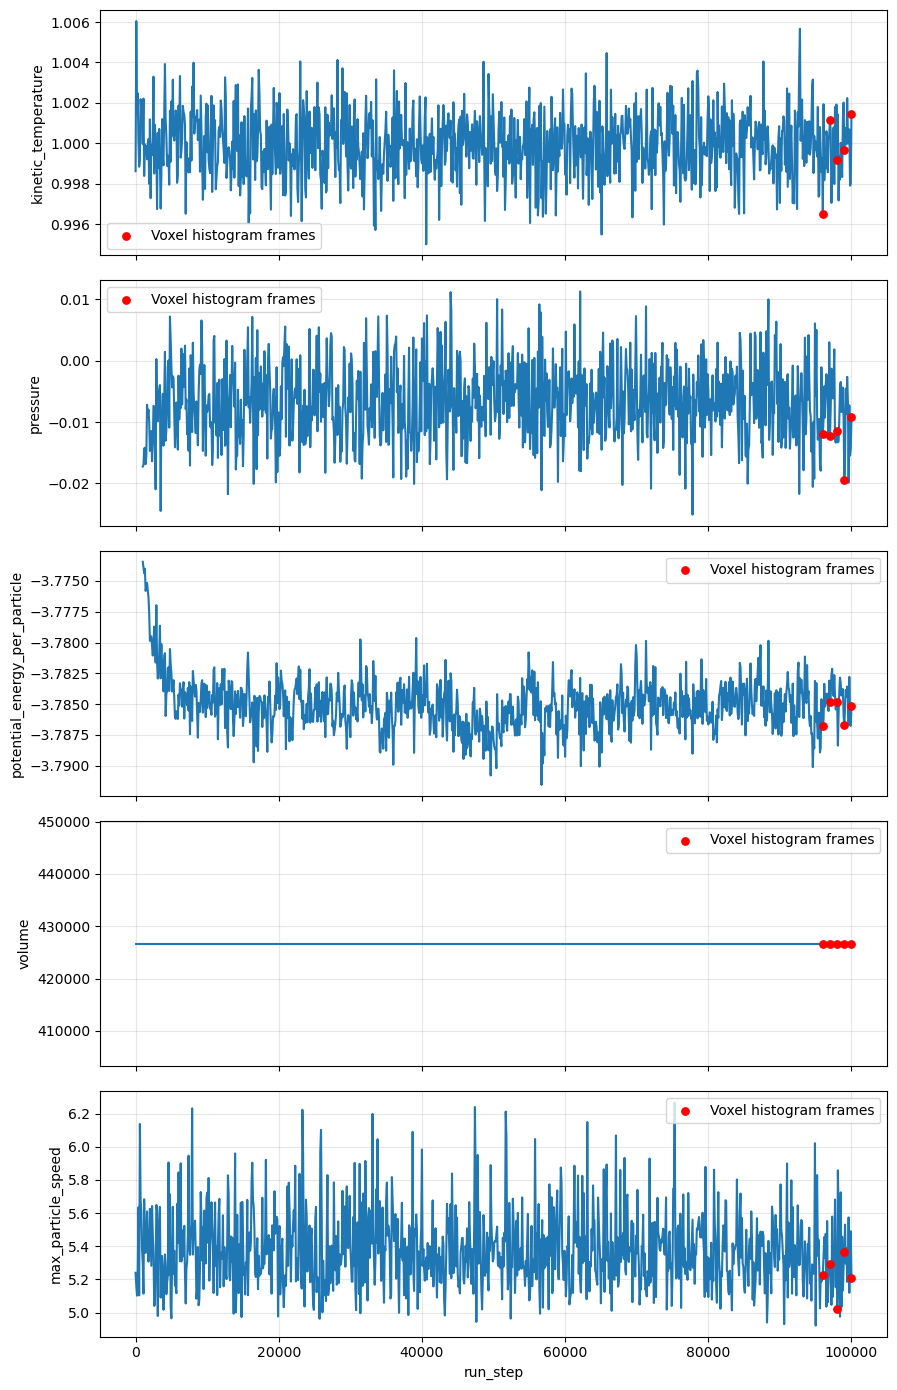

In [3]:
# Phase fit and logs
run.plot_phase_fit();
run.plot_logs();

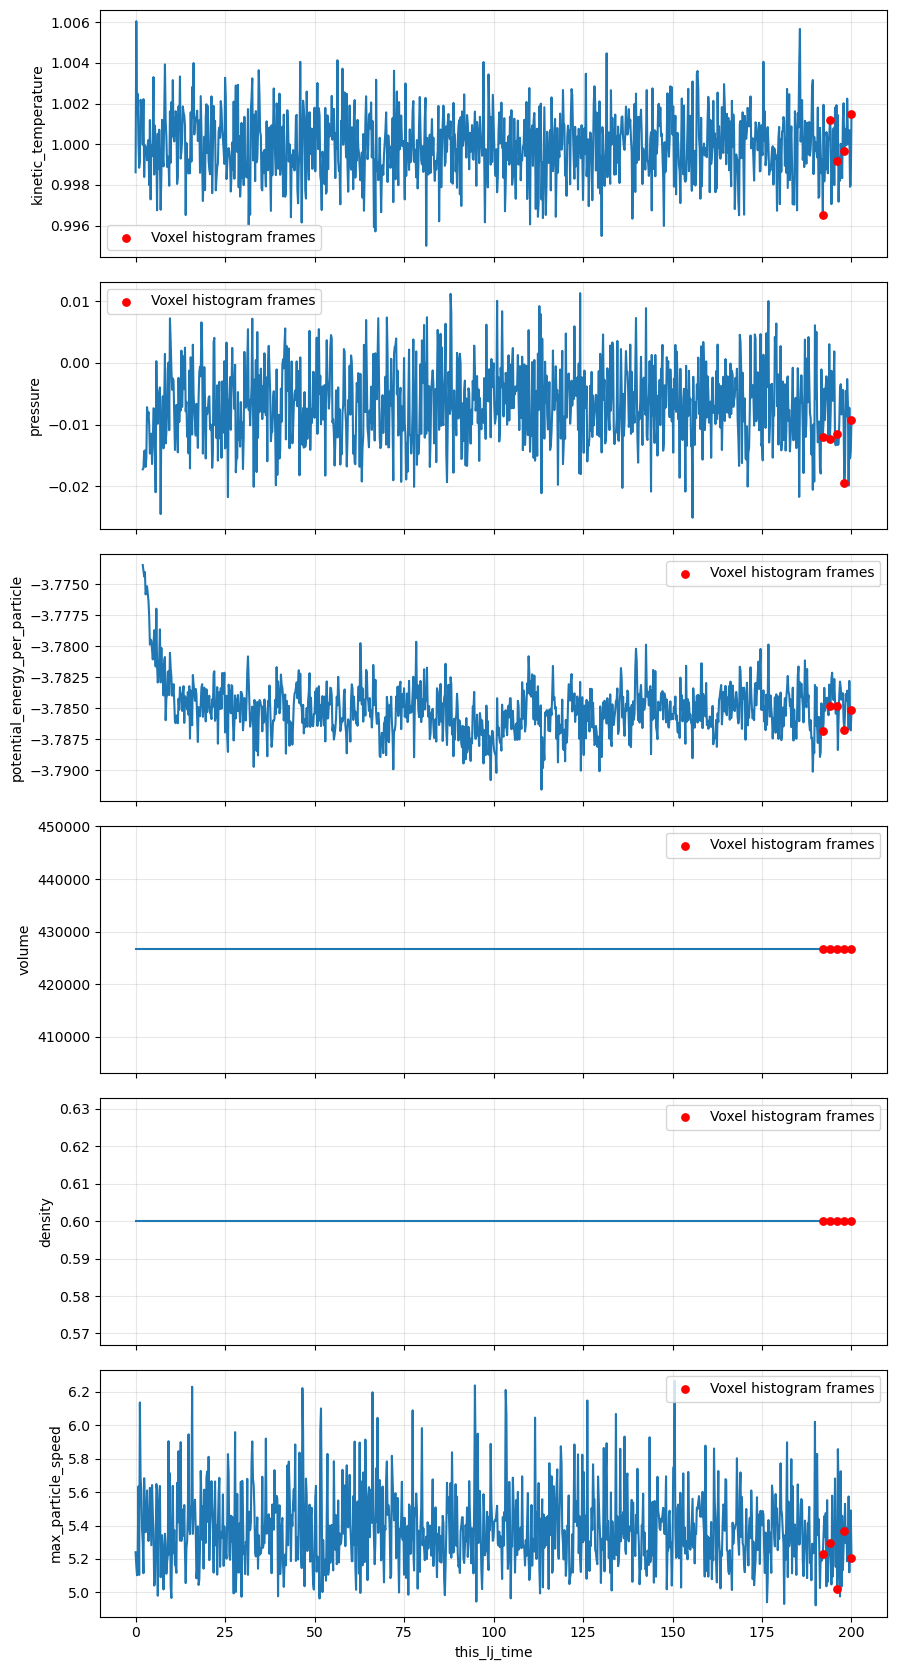

In [4]:
run.plot_logs(
    [
        "kinetic_temperature",
        "pressure",
        "potential_energy_per_particle",
        "volume",
        "density",
        "max_particle_speed",
    ],
    x="this_lj_time",
);

#x="frame"
#x="hoomd_timestep"
#x="run_step"
#x="this_lj_time"
#x="cumulative_lj_time"

In [5]:
logs = run.logs_dataframe()
metadata = run.metadata()
frame_table = run.frame_table()

for field, value in metadata.items():
    print(f"{field}: {value}")

mdsims/analysis/phase_fit/message: Voxel classification did not identify phase separation.
mdsims/analysis/phase_fit/status: Skipped_Homogeneous
mdsims/analysis/phase_separation/PE_drop/PE_drop: 0.1406840694810798
mdsims/analysis/phase_separation/PE_drop/PE_drop_z_score: 79.76022982521181
mdsims/analysis/phase_separation/PE_drop/decision_rule: either
mdsims/analysis/phase_separation/PE_drop/drop_threshold: -0.15
mdsims/analysis/phase_separation/PE_drop/last_PE_per_particle_mean: -3.7850455056813406
mdsims/analysis/phase_separation/PE_drop/last_PE_per_particle_std: 0.0017638373132747704
mdsims/analysis/phase_separation/PE_drop/method: PE_drop
mdsims/analysis/phase_separation/PE_drop/method_version: pe_drop_v1
mdsims/analysis/phase_separation/PE_drop/n_last: 100
mdsims/analysis/phase_separation/PE_drop/passes_drop_threshold: False
mdsims/analysis/phase_separation/PE_drop/passes_z_limit: False
mdsims/analysis/phase_separation/PE_drop/phase_separated: False
mdsims/analysis/phase_separation

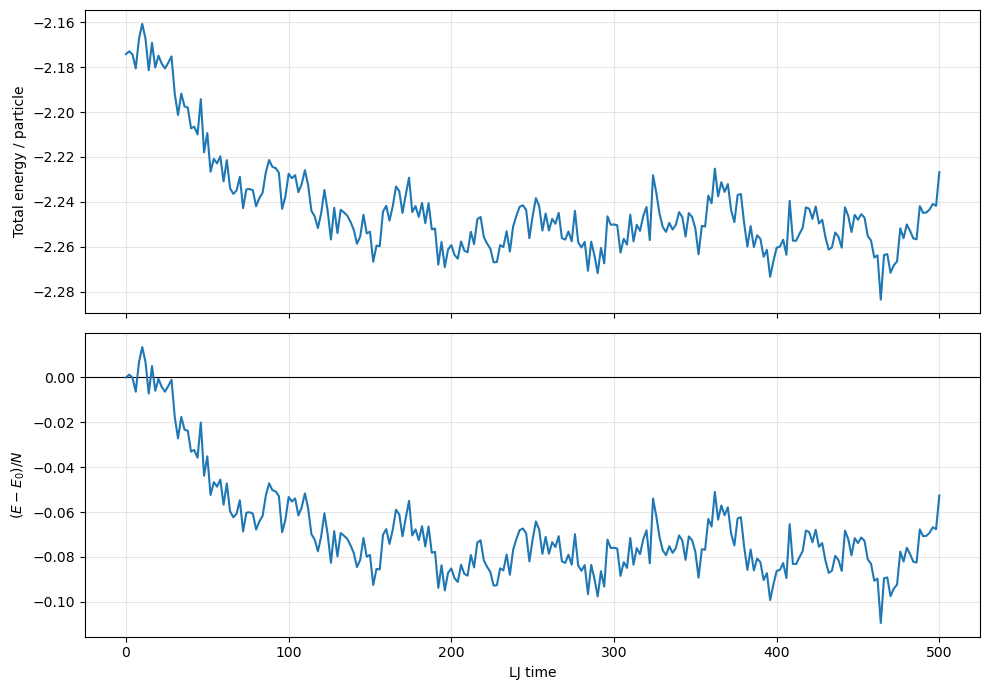

In [4]:
import matplotlib.pyplot as plt

logs = run.logs_dataframe()

logs["total_energy"] = (
    logs["kinetic_energy"]
    + logs["potential_energy"]
)

logs["total_energy_per_particle"] = (
    logs["total_energy"]
    / logs["num_particles"]
)

initial_energy = logs["total_energy_per_particle"].iloc[0]

logs["energy_change_per_particle"] = (
    logs["total_energy_per_particle"]
    - initial_energy
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    logs["this_lj_time"],
    logs["total_energy_per_particle"],
)

axes[0].set_ylabel("Total energy / particle")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].plot(
    logs["this_lj_time"],
    logs["energy_change_per_particle"],
)

axes[1].set_xlabel("LJ time")
axes[1].set_ylabel(r"$(E-E_0)/N$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()